In [1]:
!pip install -q tokenizers torch matplotlib seaborn

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import urllib.request
import os
import math

# 1. Download Dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "tinyshakespeare.txt"
if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)

with open(filename, 'r', encoding='utf-8') as f:
    text = f.read()

# 2. Train Custom BPE Tokenizer (Vocab <= 500)
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=500, special_tokens=["[UNK]", "[PAD]"])
tokenizer.train(files=[filename], trainer=trainer)

# Encode text
encoded = tokenizer.encode(text)
data = torch.tensor(encoded.ids, dtype=torch.long)

# 3. Data Split (80/20)
n = int(0.8 * len(data))
train_data = data[:n]
val_data = data[n:]

# 4. PyTorch Dataset
class ShakespeareDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        # Input: first N tokens, Target: shifted by one
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

# --- 1. UPDATED DATA SETUP ---
seq_len = 128    # Increased context window
batch_size = 32  # Lowered to prevent Out-Of-Memory errors

train_dataset = ShakespeareDataset(train_data, seq_len)
val_dataset = ShakespeareDataset(val_data, seq_len)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

# --- 2. MAXED-OUT CONFIG ---
class Config:
    vocab_size = 500
    block_size = 128   # Keep the longer context window!
    n_embd = 128       # Revert back to smaller dimensions
    n_head = 4         # Revert back to 4 heads
    n_layer = 2        # Revert back to 2 layers
    dropout = 0.2      # Bump dropout slightly to 30% for extra safety if needed

In [2]:
# --- 3. ROPE IMPLEMENTATION ---
def apply_rotary_emb(x, cos, sin):
    # Split x into two halves for rotation
    d = x.shape[-1]
    x1 = x[..., :d//2]
    x2 = x[..., d//2:]
    x_rotated = torch.cat([-x2, x1], dim=-1)

    # Reshape cos and sin for broadcasting: (1, T, 1, head_dim)
    cos = cos.unsqueeze(0).unsqueeze(2)
    sin = sin.unsqueeze(0).unsqueeze(2)

    return (x * cos) + (x_rotated * sin)

class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=2048):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        t = torch.arange(max_seq_len).type_as(inv_freq)
        freqs = torch.outer(t, inv_freq)
        # Duplicate frequencies for both halves of the vector
        self.register_buffer("cos", torch.cat([freqs, freqs], dim=-1).cos())
        self.register_buffer("sin", torch.cat([freqs, freqs], dim=-1).sin())

    def forward(self, q, k, seq_len):
        cos = self.cos[:seq_len]
        sin = self.sin[:seq_len]
        return apply_rotary_emb(q, cos, sin), apply_rotary_emb(k, cos, sin)

# --- 4. UPDATED ATTENTION WITH ROPE ---
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=False)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.n_head = config.n_head
        self.n_embd = config.n_embd

        # Initialize RoPE for the specific head dimension
        self.rope = RotaryPositionalEmbedding(config.n_embd // config.n_head, config.block_size)

        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)

        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()

        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head)
        q = q.view(B, T, self.n_head, C // self.n_head)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        # Apply RoPE to Queries and Keys BEFORE transposing for attention
        q, k = self.rope(q, k, T)

        # Transpose after rotation
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att_weights = F.softmax(att, dim=-1)
        att_weights = self.attn_dropout(att_weights)

        y = att_weights @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.c_proj(y)
        y = self.resid_dropout(y)
        return y, att_weights

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        norm_x = x.norm(2, dim=-1, keepdim=True)
        rms_x = norm_x * (x.shape[-1] ** -0.5)
        x_normed = x / (rms_x + self.eps)
        return self.weight * x_normed

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout) # Add here
        )

    def forward(self, x):
        return self.net(x)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = RMSNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = RMSNorm(config.n_embd)
        self.mlp = FeedForward(config)

    def forward(self, x):
        attn_out, att_weights = self.attn(self.ln_1(x))
        x = x + attn_out
        x = x + self.mlp(self.ln_2(x))
        return x, att_weights

In [3]:
class TinyTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        # REMOVED: self.pos_emb = PositionalEncoding(...)
        self.drop = nn.Dropout(config.dropout)

        self.blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layer)])
        self.ln_f = RMSNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # ADD THIS LINE: Tie the weights!
        self.lm_head.weight = self.token_emb.weight

    def forward(self, idx, targets=None):
        B, T = idx.size()
        x = self.token_emb(idx)
        x = self.drop(x) # Apply dropout directly after token embedding

        attention_maps = []
        for block in self.blocks:
            x, att_weights = block(x)
            attention_maps.append(att_weights)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss, attention_maps

config = Config()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = TinyTransformer(config).to(device)

In [4]:
import math

epochs = 30

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.005)

# Set up the Cosine Annealing Scheduler
total_steps = epochs * len(train_loader)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-5)

train_losses, val_losses, val_ppls = [], [], []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits, loss, _ = model(x, targets=y)
        loss.backward()
        optimizer.step()
        scheduler.step() # Step the scheduler every batch!

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits, loss, _ = model(x, targets=y)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_ppl = math.exp(avg_val_loss)
    val_ppls.append(val_ppl)

    # Let's also print the current learning rate to watch it decay
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1} | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | PPL: {val_ppl:.4f}")

Epoch 1 | LR: 0.000997 | Train Loss: 4.3817 | Val Loss: 4.0067 | PPL: 54.9650
Epoch 2 | LR: 0.000989 | Train Loss: 3.4250 | Val Loss: 3.9325 | PPL: 51.0333
Epoch 3 | LR: 0.000976 | Train Loss: 3.3023 | Val Loss: 3.8997 | PPL: 49.3873
Epoch 4 | LR: 0.000957 | Train Loss: 3.2439 | Val Loss: 3.8954 | PPL: 49.1735
Epoch 5 | LR: 0.000934 | Train Loss: 3.2074 | Val Loss: 3.8967 | PPL: 49.2391
Epoch 6 | LR: 0.000905 | Train Loss: 3.1819 | Val Loss: 3.8883 | PPL: 48.8294
Epoch 7 | LR: 0.000873 | Train Loss: 3.1624 | Val Loss: 3.8979 | PPL: 49.2996
Epoch 8 | LR: 0.000836 | Train Loss: 3.1467 | Val Loss: 3.8928 | PPL: 49.0457
Epoch 9 | LR: 0.000796 | Train Loss: 3.1337 | Val Loss: 3.8901 | PPL: 48.9159
Epoch 10 | LR: 0.000752 | Train Loss: 3.1223 | Val Loss: 3.8907 | PPL: 48.9429
Epoch 11 | LR: 0.000706 | Train Loss: 3.1126 | Val Loss: 3.8998 | PPL: 49.3935
Epoch 12 | LR: 0.000658 | Train Loss: 3.1037 | Val Loss: 3.8966 | PPL: 49.2334
Epoch 13 | LR: 0.000608 | Train Loss: 3.0961 | Val Loss: 3.88

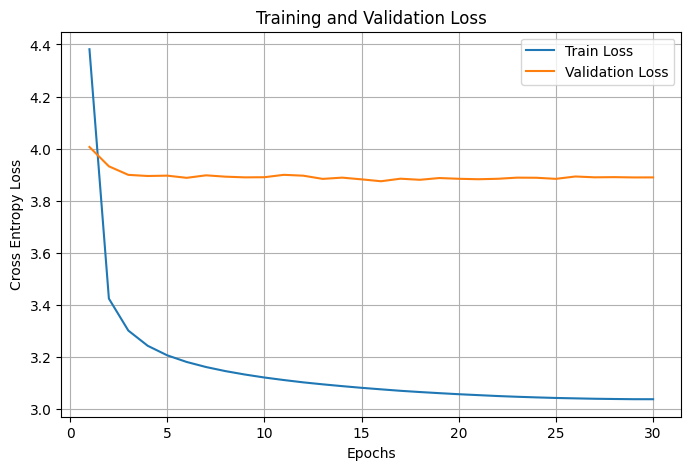

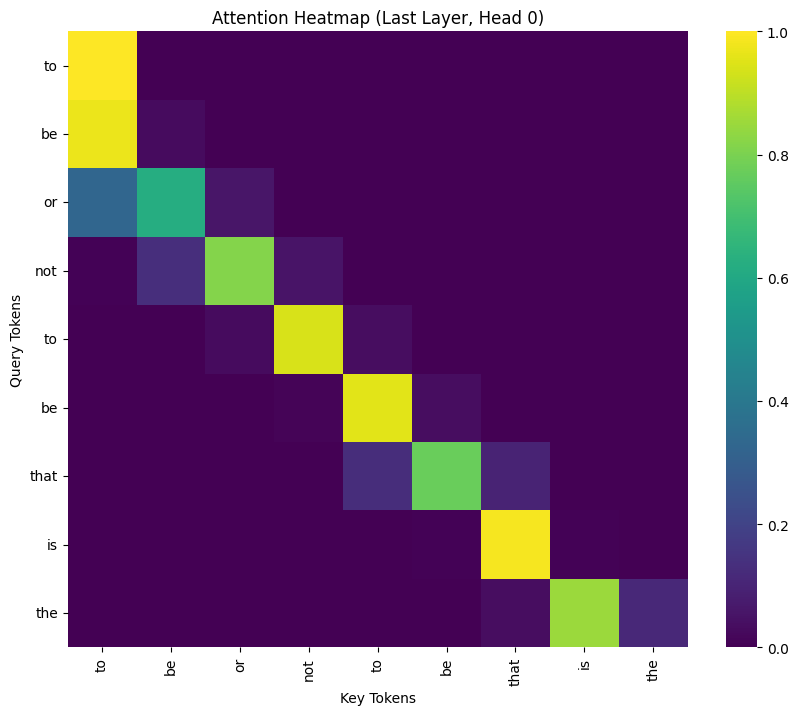

In [5]:
# 1. Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2. Attention Visualization
def plot_attention(model, text_input, tokenizer, device):
    model.eval()
    encoded = tokenizer.encode(text_input).ids
    x = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)
    tokens = [tokenizer.decode([i]) for i in encoded]

    with torch.no_grad():
        _, _, attention_maps = model(x)

    # Get attention from the last layer, first head
    # Shape: (Batch, Heads, SeqLen, SeqLen)
    attn = attention_maps[-1][0, 0, :, :].cpu().numpy()

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
    plt.title("Attention Heatmap (Last Layer, Head 0)")
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

sample_text = "to be or not to be that is the"
plot_attention(model, sample_text, tokenizer, device)

In [6]:
def generate_text(model, start_text, max_new_tokens=50):
    model.eval()
    encoded = tokenizer.encode(start_text).ids
    x = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            # Crop to block size
            x_cond = x[:, -config.block_size:]
            logits, _, _ = model(x_cond)
            # Take logits for the last token
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            # Sample next token
            next_token = torch.multinomial(probs, num_samples=1)
            x = torch.cat((x, next_token), dim=1)

    return tokenizer.decode(x[0].tolist())

print(generate_text(model, "O Romeo, Romeo! wherefore art thou Romeo? "))

O Rome o , Rome o ! where fore art thou Rome o ? A ll : A y , you ' ll take our or ac le : I am well ab out To s la ught er ' s see king li ght and c r ue l We ad , you ch o e . C O M IN IUS :
